# Инициализация 

## Импорт данных

Выберем несколько эмбеддинг-моделей: 
- voyage-large-2 от Voyage
- Marqo
- text-embedding-3-large от O penAI
- BioGPT от Microsoft

In [1]:
import yaml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

In [2]:
with open('../config.yaml') as f:
    config = yaml.safe_load(f)
    OPEN_AI_KEY = config['open_ai']['open_ai_key']
    VOYAGE_AI_KEY = config['voyage_ai']['voyage_key']

models = []

Для демонстрации выбрали статьи с [PubMed](https://pubmed.ncbi.nlm.nih.gov/) за последние пять лет по этим [MeSH terms](https://meshb.nlm.nih.gov/treeView):

- Diabetes, Gestational [C19.246.200]
- Latent Autoimmune Diabetes in Adults [C19.246.656]
- Prediabetic State [C19.246.774]
- Так как мы знаем, что класса 3, попробуем разделить их на k-means

In [3]:
# df = pd.read_csv('data/diabetes.csv')

In [4]:
import ast

df = pd.read_csv("openai_voyage.csv")

df['voyage'] = df['voyage'].apply(ast.literal_eval)
df['openai'] = df['openai'].apply(ast.literal_eval)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   pmid      300 non-null    int64 
 1   title     300 non-null    object
 2   category  300 non-null    object
 3   abstract  300 non-null    object
 4   text      300 non-null    object
 5   voyage    300 non-null    object
 6   openai    300 non-null    object
dtypes: int64(1), object(6)
memory usage: 16.5+ KB


In [5]:
category_counts = df['category'].value_counts()
category_counts

category
gestational    100
lada           100
prediabetes    100
Name: count, dtype: int64

todo: сбалансировать что ли

In [6]:
# df = df.groupby('category').apply(lambda x: x.sample(n=100, random_state=42)).reset_index(drop=True) todo remove 

In [7]:
df.head()

,pmid,title,category,abstract,text,voyage,openai
0,34546002,Early gut dysbiosis could be an indicator of u...,gestational,Highlights At the time of gestational diabetes...,Early gut dysbiosis could be an indicator of u...,"[-0.0007559357909485698, 0.009320765733718872,...","[-0.025438660755753517, 0.014910029247403145, ..."
1,37678923,Racial and Ethnic Inequities in Development of...,gestational,Objective:\n \n \n To estimat...,Racial and Ethnic Inequities in Development of...,"[-0.023291515186429024, 0.020983217284083366, ...","[-0.012501530349254608, -0.005679131019860506,..."
2,31891955,Maternal Weight Gain and Infant Birth Weight i...,gestational,Objective:\n \n \n The aim of...,Maternal Weight Gain and Infant Birth Weight i...,"[-0.0026243943721055984, 0.019972020760178566,...","[0.02455088682472706, 0.01618306152522564, -0...."
3,37936027,The effect of gestational diabetes mellitus on...,gestational,Aims:\n \n \n The association...,The effect of gestational diabetes mellitus on...,"[-0.0005134319653734565, 0.012960294261574745,...","[-0.01997675560414791, 0.038829218596220016, -..."
4,38414896,Relationships between triglyceride-glucose ind...,gestational,Background:\n \n \n The conne...,Relationships between triglyceride-glucose ind...,"[0.004854550119489431, 0.015022511593997478, 0...","[-0.028489820659160614, -0.029437676072120667,..."


## Embeddings

In [8]:
# todo df['texts'] -> texts

def get_embeddings(texts, model, batch_size=1000):
    embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        embeddings += model(batch_texts)
    
    return embeddings

### Voyage
https://docs.voyageai.com/docs/embeddings

In [9]:
import voyageai

vo = voyageai.Client(api_key=VOYAGE_AI_KEY)

def get_voyageai(texts):
    embeddings = vo.embed(texts, model="voyage-large-2", input_type="document").embeddings
    return embeddings

In [10]:
# df['voyage'] = get_embeddings(get_voyageai, 100)

### Marqo
https://docs.marqo.ai/latest/quickstart/marqo/starter-guides/text-search/

In [11]:
# from marqo import Client

# def get_marqo(api_key, texts, index_name="text-embedding-index"):
#     try:
#         mq = Client("https://api.marqo.ai", api_key=api_key)
#         index_settings = {
#             "model": "text-embedding-3-large", 
#              "inferenceType": "marqo.CPU.large"
#             }
#         mq.create_index(index_name, settings_dict=index_settings)
#         embeddings = []
#         for text in texts:
#             response = mq.index(index_name).add_documents([{"text": text}], device="cpu")
#             embeddings.append(response["processingResults"][0]["data"]["_embedding"])
#         return embeddings
#     except Exception as e:
#         print("Error processing embeddings:", e)
#         return [None] * len(texts)

### OpenAI
https://platform.openai.com/docs/guides/embeddings#embedding-models

In [12]:
from openai import OpenAI

client = OpenAI(api_key=OPEN_AI_KEY)

def get_openai(texts):
    response = client.embeddings.create(input=texts, model="text-embedding-3-large")
    return [item.embedding for item in response.data]

In [13]:
# df['openai'] = get_embeddings(get_openai, 1500)

### BioGPT
и biogpt — чтобы у нас был хотя бы один медицинский 

In [14]:
# from typing import Union

# import torch
# from sentence_transformers import SentenceTransformer, util
# from transformers import AutoModel, AutoTokenizer


# class BioGPT:
#     """https://huggingface.co/microsoft/biogpt"""

#     tokenizer = AutoTokenizer.from_pretrained("microsoft/biogpt")
#     model = AutoModel.from_pretrained("microsoft/biogpt")

#     def __init__(self, max_input_len: int = 512) -> None:
#         self.max_length = max_input_len

#     def mean_pooling(self, model_output: torch.tensor, attention_mask: torch.tensor) -> torch.tensor:
#         token_embeddings = model_output["last_hidden_state"]
#         input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
#         sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
#         sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
#         return sum_embeddings / sum_mask

#     def max_pooling(self, model_output: torch.tensor, attention_mask: torch.tensor) -> torch.tensor:
#         token_embeddings = model_output["last_hidden_state"]
#         input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
#         return torch.max(
#             token_embeddings * input_mask_expanded + (1.0 - input_mask_expanded) * (-1e9), 1
#         ).values  # noqa: PD011

#     def last_token_embedding(self, model_output: torch.tensor, attention_mask: torch.tensor) -> torch.tensor:
#         token_embeddings = model_output["last_hidden_state"]
#         last_token_indexes = torch.sum(attention_mask, dim=1) - 1
#         return token_embeddings[range(token_embeddings.shape[0]), last_token_indexes]

#     def encode(self, sentences: Union[str, list[str]], pooling: str = "last") -> np.ndarray | None:
#         encoded_input = self.tokenizer(
#             sentences, padding=True, truncation=True, max_length=self.max_length, return_tensors="pt"
#         )

#         with torch.no_grad():
#             model_output = self.model(**encoded_input)

#         if pooling == "mean":
#             return self.mean_pooling(model_output, encoded_input["attention_mask"])  # [0].numpy()
#         if pooling == "max":
#             return self.max_pooling(model_output, encoded_input["attention_mask"])  # [0].numpy()
#         if pooling == "last":
#             return self.last_token_embedding(model_output, encoded_input["attention_mask"])  # [0].numpy()
#         return None


# def get_model(model_name: str) -> Union[SentenceTransformer, BioGPT] | None:
#     if model_name in [
#         "sentence-transformers/multi-qa-mpnet-base-dot-v1",
#         "thenlper/gte-base",
#         "BAAI/bge-base-en-v1.5",
#         "intfloat/e5-base-v2",
#     ]:
#         return SentenceTransformer(model_name)
#     if model_name == "biogpt":
#         return BioGPT()
#     return None

In [15]:
methods = [("openai", get_openai), 
           ("voyage", get_voyageai)]

# Эмбеддинги запросов

In [16]:
question_pairs = [
    ("Сonnection between LDH markers and persistent exhaustion", "How are lactate dehydrogenase levels and chronic fatigue related?"),
    ("What published data is available for impact on daily activities with anti-C5 therapy?", "Is there evidence on how C5i impacts patients' ability to perform daily tasks?"),
    ("Is fingolimod a comparable alternative to dimethyl fumarate in multiple sclerosis management?", "Can Gilenya be used as a replacement for Tecfidera in treating multiple sclerosis?"),
    ("Addressing IVN in the treatment approach for PNH.", "Intravascular hemolysis as a factor in managing paroxysmal nocturnal hemoglobinuria."),
    ("Do high D dimer levels influence the risk of developing blood clots?", "What is the relationship between elevated D-dimer levels and thrombosis risk?"),
    ("How long have you been ill?", "Since when have you been experiencing these symptoms?"),
    ("Optical coherence tomography applications in diagnosing retinal diseases.", "What is the use of OCT in clinical assessments for retinal disorders?"),
    ("Symptoms of anemia?", "How does anemia manifest?"),
    ("The advantages of maintaining a fitness routine.", "What are the health benefits of regular physical activity")
]

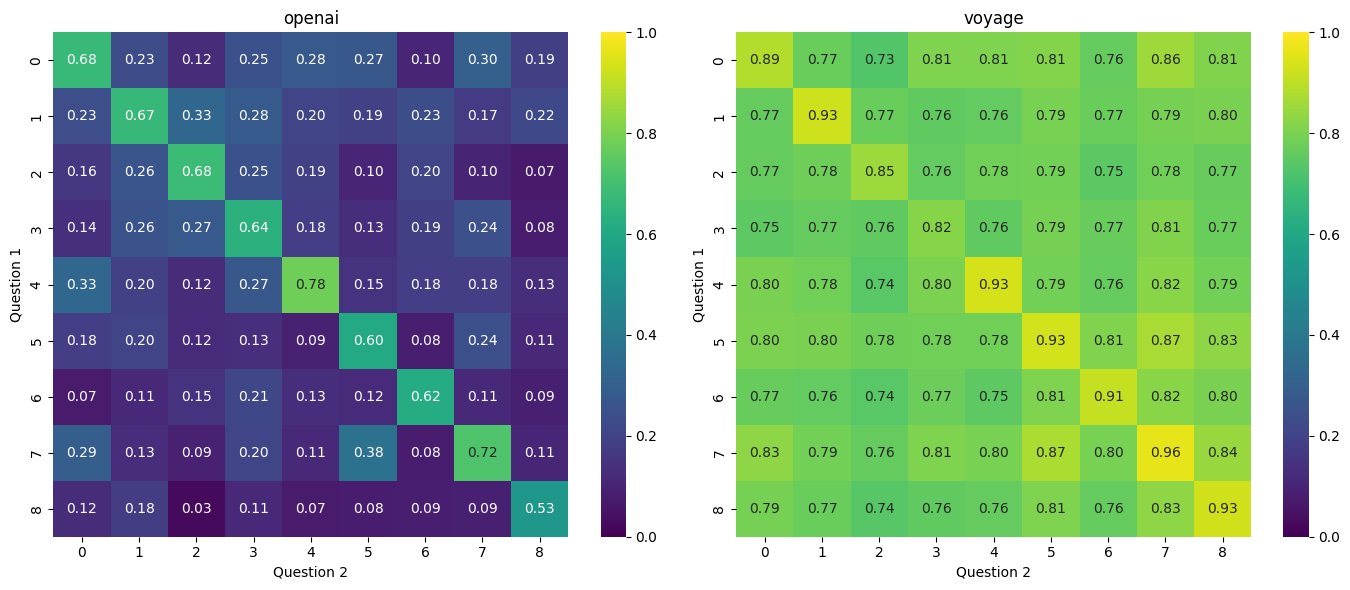

In [17]:
plt.figure(figsize=(14, 6))

for i, (title, method) in enumerate(methods, start=1):
    # todo разве не должна быть матрица симметричной?
    
    embeddings_q1 = method([pair[0] for pair in question_pairs])
    embeddings_q2 = method([pair[1] for pair in question_pairs])
    
    similarity_matrix = cosine_similarity(embeddings_q1, embeddings_q2)
    
    plt.subplot(1, 2, i)
    sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='viridis', cbar=True, vmin=0, vmax=1)
    plt.title(title)
    
    plt.xlabel('Question 2')
    plt.ylabel('Question 1')
    
plt.tight_layout()
plt.show()

# Эмбеддинги документов

In [18]:
import umap

from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score

from bokeh.layouts import row 
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.plotting import figure, output_notebook, show

In [19]:
category_colors = {'gestational': '#1f77b4', 
                   'prediabetes': '#ff7f0e', 
                   'lada': '#2ca02c'}

df['color'] = df['category'].map(category_colors)
df['label'] = df['category'] + ' ' + df['pmid'].astype(str) + ': ' + df['title']

In [20]:
output_notebook()

def create_umap_plot(df, embedding_column):
    
    data = np.array(df[embedding_column].tolist())
    
    reducer = umap.UMAP(n_neighbors=10, min_dist=0.05)
    projection = reducer.fit_transform(data)
    
    source = ColumnDataSource(data={
        'x': projection[:, 0],
        'y': projection[:, 1],
        'colors': df['color'],
        'labels': df['label']
    })
    
    plot = figure(title=f"'UMAP projection of {embedding_column} embeddings'", 
                  width=400, height=350, tools="pan,wheel_zoom,box_zoom,reset")
    plot.add_tools(HoverTool(tooltips=[("", "@labels")]))
    plot.scatter('x', 'y', color='colors', source=source, size=4, alpha=0.7)

    return plot

Loading BokehJS ...

In [21]:
plot1 = create_umap_plot(df, 'voyage')
plot2 = create_umap_plot(df, 'openai')

show(row(plot1, plot2))

In [22]:
columns = ['voyage', 'openai']
results = []

umap_reducer = umap.UMAP(n_components=5, random_state=42)  # todo remove random state 

for column in columns:
    reduced = umap_reducer.fit_transform(df[column].tolist())
    
    clustering = SpectralClustering(n_clusters=3, random_state=42, affinity='nearest_neighbors', n_neighbors=10)
    clusters = clustering.fit_predict(reduced)
    
    df[f'{column}_cluster'] = clusters
    labels_true = df['category']
    labels_pred = df[f'{column}_cluster']
    
    ari_score = adjusted_rand_score(labels_true, labels_pred)
    silhouette = silhouette_score(np.vstack(reduced), labels_pred)
    
    results.append([column, round(ari_score, 2), round(silhouette, 2)])

/Users/mariachakchurina/projects/bioage/experiments/venv/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [23]:
pd.DataFrame(results, columns=['Column', 'ARI', 'Silhouette'])

,Column,ARI,Silhouette
0,voyage,0.84,0.55
1,openai,0.87,0.62


# Как запросы и документы работают вместе 

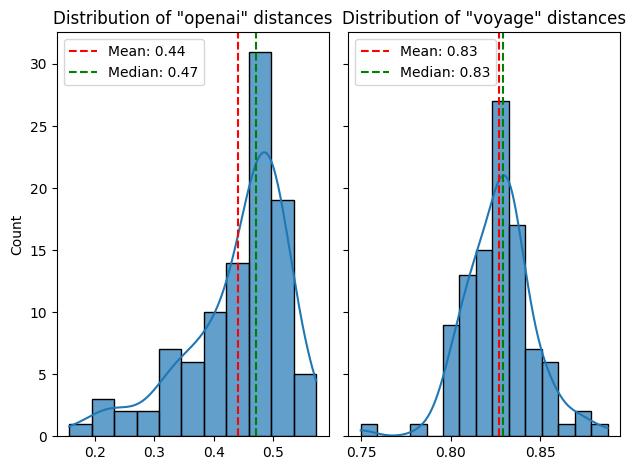

In [24]:
data = df[df['category'] == 'gestational']
fig, axes = plt.subplots(1, len(methods), sharey=True)

for i, (model, method) in enumerate(methods):
    category_embedding = method(["Gestational Diabetes"])
    similarities = cosine_similarity(data[model].tolist(), category_embedding).flatten()

    mean_similarity = np.mean(similarities)
    median_similarity = np.median(similarities)

    sns.histplot(similarities, kde=True, alpha=0.7, ax=axes[i])
    axes[i].axvline(mean_similarity, color='red', linestyle='--', label=f'Mean: {mean_similarity:.2f}')
    axes[i].axvline(median_similarity, color='green', linestyle='--', label=f'Median: {median_similarity:.2f}')
    axes[i].set_title(f'Distribution of "{model}" distances')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Устойчивость к ошибкам

## Опечатки

Создадим опечатки вручную (или автоматически с помощью библиотеки typo). Неважно, как сделать — руками или сгенерировать, просто убедитесь, чтобы были представлены ошибки разных типов. 

https://pypi.org/project/typo/

In [25]:
import random
import typo

In [26]:
typos = {
    'biomarkers': 'nbiomarkers',  # лишняя в начале
    'transfusions': 'transfusilons',  # лишняя в середине 
    'ravulizumab': 'ravulizumanb',  # лишняя в конце 
    'clinical trial': 'xlinical trial',  # ошибка в начале
    'meningococcal vaccine': 'meningococcql vacine',  # ошибка в середине
    'thrombosis': 'thrombosie',  # ошибка в конце
    'ozempik': 'ozemopik',  # похожий символ в начале
    'diagnosis': 'diaqnosis',  # похожий символ в середине 
    'fatigue': 'fatiguc', # похожий символ в конце 
    'patient': 'ptaient',  # char swap в начале
    'myasthenia': 'mysathenia',  # char swap в середине
    'therapy': 'therpay',  # char swap в конце
    'pregnancy': 'regnancy',  # пропуск в начале 
    'symptoms': 'symptos',  # пропуск в середине 
    'epidemiology': 'epidemiolog'  # пропуск в конце 
}  

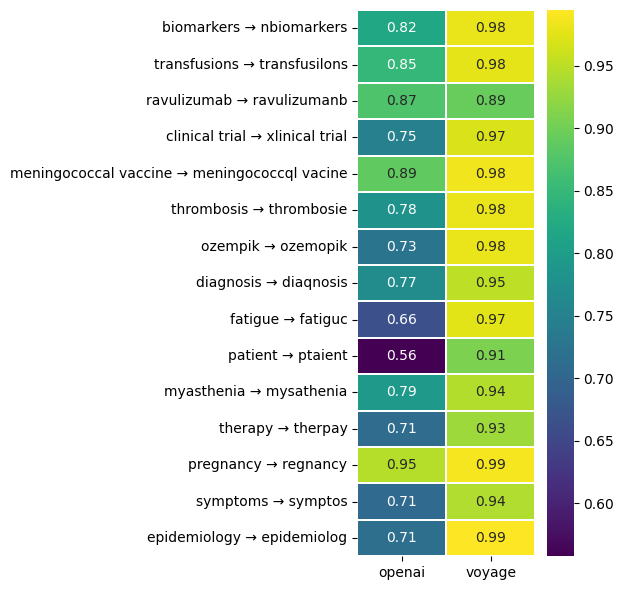

In [27]:
scores = []

for model, method in methods:
    embeddings_original = method(list(typos.keys()))
    embeddings_typos = method(list(typos.values()))
    similarity_scores = np.diag(cosine_similarity(embeddings_original, embeddings_typos))
    scores.append(similarity_scores)

scores_matrix = np.array(scores).T
yticklabels = [f"{original} → {typo}" for original, typo in typos.items()]

fig, ax = plt.subplots(figsize=(6, len(typos) * 0.4))
sns.heatmap(scores_matrix, annot=True, fmt=".2f", yticklabels=yticklabels, 
            xticklabels=[m[0] for m in methods], cmap='viridis', linewidths=.25, ax=ax)

# plt.title("Why spelling still matters")
# plt.xlabel("Models")
# plt.ylabel("Terms")
plt.tight_layout()
plt.show()

## Токенизация

In [28]:
for model in models:
    print("Model: ", model)
    for term in typos:
        print(f"{term}: {model.tokenizer.tokenize(term)}")
        print(f"{typos[term]}: {model.tokenizer.tokenize(typos[term])}\n")

In [29]:
import tiktoken

tokenizer = tiktoken.encoding_for_model("text-embedding-3-large")

for term in typos:
    encoded_term = tokenizer.encode(term)
    decoded_tokens = [tokenizer.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_term]
        
    encoded_typo = tokenizer.encode(typos[term])
    decoded_typo_tokens = [tokenizer.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_typo]

    print(f"{term}: {'-'.join(decoded_tokens)} / {'-'.join(decoded_typo_tokens)}")


biomarkers: bi-om-arkers / n-bi-om-arkers
transfusions: trans-f-usions / trans-f-us-il-ons
ravulizumab: r-av-ul-iz-um-ab / r-av-ul-iz-uman-b
clinical trial: clinical-trial / x-lin-ical-trial
meningococcal vaccine: men-ing-oc-oc-cal-vaccine / men-ing-oc-occ-ql-vac-ine
thrombosis: th-rom-b-osis / th-rom-bos-ie
ozempik: oz-emp-ik / oz-em-op-ik
diagnosis: di-agnosis / dia-qn-osis
fatigue: fat-igue / fat-ig-uc
patient: patient / pta-ient
myasthenia: my-ast-hen-ia / mys-ath-enia
therapy: therapy / ther-pay
pregnancy: preg-n-ancy / regn-ancy
symptoms: sym-ptoms / sym-pt-os
epidemiology: ep-id-emi-ology / ep-id-emi-olog


# Работа с доменными терминами 

In [30]:
import nltk
import ssl

ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('wordnet')

from nltk.corpus import wordnet
from tqdm.auto import tqdm

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mariachakchurina/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [31]:
words = list(wordnet.words())
len(words)

147306

In [32]:
# todo remove
words = random.sample(words, 300)

In [33]:
terms = [
    "Selective serotonin reuptake inhibitor",  # Класс антидепрессантов
    "BBB disruption therapy",  # Метод временного нарушение ГЭБ для доставки лекарств к тканям мозга
    "CAR T-cell therapy",  # Иммунотерапия, в которой модифицированные T-клетки атакуют раковые
    "Meningococcal vaccine",  # Вакцина против инфекции, вызывающей менингит
    "Zolgensma",  # Генная терапия спинальной мышечной атрофии
    "ReoPro",  # Препарат, предотвращающий свертывание крови при операциях на сосудах
    "Rickettsia prowazekii",  # Бактерия, которая вызывает эпидемический сыпной тиф
    "Neurofilament light chain",  # Биомаркер для диагностики неврологических расстройств
    "lncRNA",  # Некодирующие РНК с функцией регулирования генов
    "Antisense oligonucleotide",  # Короткие синтетические ДНК или РНК, в терапии генетических заболеваний и рака
    "Gamma Knife procedure",  # Неврологическая радиохирургия для лечения опухолей мозга
    "Cladribine",  # Препарат для лечения рассеянного склероза
    "PD-L1 mAbs",  # Моноклональные антитела, помогающие иммунной системе распознавать и уничтожать раковые клетки
    "Kabuki syndrome"  # Редкое генетическое заболевание
]

In [34]:
wordnet_embeddings = get_embeddings(words, get_openai, 1500)
terms_embeddings = get_embeddings(terms, get_openai)

similarities = cosine_similarity(terms_embeddings, wordnet_embeddings)

for term, term_similarities in zip(terms, similarities):
    
    top_indices = np.argsort(term_similarities)[-3:][::-1]
    top_scores = term_similarities[top_indices]
    top_words = [words[i] for i in top_indices]
    
    print(f"Term: {term}")
    for word, score in zip(top_words, top_scores):
        print(f"  {word}: {score:.2f}")
    print()

Term: Selective serotonin reuptake inhibitor
  tryptophane: 0.31
  hypertensin: 0.26
  mineralocorticoid: 0.25

Term: BBB disruption therapy
  thrombokinase: 0.28
  corditis: 0.26
  mind-altering: 0.24

Term: CAR T-cell therapy
  corditis: 0.25
  kala-azar: 0.22
  auto_race: 0.21

Term: Meningococcal vaccine
  strep: 0.24
  moeller's_glossitis: 0.22
  corditis: 0.21

Term: Zolgensma
  hypertensin: 0.24
  genus_ondatra: 0.23
  osmerus: 0.23

Term: ReoPro
  thrombokinase: 0.41
  reconstitute: 0.33
  hypertensin: 0.30

Term: Rickettsia prowazekii
  tick-weed: 0.35
  prokaryotic: 0.31
  epizoon: 0.31

Term: Neurofilament light chain
  pycnotic: 0.29
  glutamate: 0.29
  lamina_arcus_vertebrae: 0.27

Term: lncRNA
  pycnotic: 0.30
  lesion: 0.30
  prokaryotic: 0.29

Term: Antisense oligonucleotide
  hypertensin: 0.25
  glutamate: 0.24
  osmerus: 0.22

Term: Gamma Knife procedure
  lesion: 0.22
  globus_pallidus: 0.22
  nuke: 0.22

Term: Cladribine
  kala-azar: 0.28
  chrysosplenium: 0.24
  sp

In [41]:
results = {}

for model, method in methods:
    wordnet_embeddings = get_embeddings(words, method, 100)
    terms_embeddings = get_embeddings(terms, method, 100)
    similarities = cosine_similarity(terms_embeddings, wordnet_embeddings)
    
    results[model] = []
    for term, term_similarities in zip(terms, similarities):
        top_indices = np.argsort(term_similarities)[-3:][::-1]
        top_scores = term_similarities[top_indices]
        top_words = [words[i] for i in top_indices]
        results[model].append(", ".join([f"{word} ({score:.2f})" for word, score in zip(top_words, top_scores)]))


df = pd.DataFrame(results, index=terms)

In [40]:
df.head(20)

,openai,voyage
Selective serotonin reuptake inhibitor,"tryptophane (0.31)\n, hypertensin (0.26)\n, mi...","glutamate (0.88)\n, good (0.87)\n, hypertensin..."
BBB disruption therapy,"thrombokinase (0.28)\n, corditis (0.26)\n, min...","lesion (0.88)\n, mesothelium (0.87)\n, strep (..."
CAR T-cell therapy,"corditis (0.25)\n, kala-azar (0.22)\n, auto_ra...","lesion (0.89)\n, mesothelium (0.88)\n, strep (..."
Meningococcal vaccine,"strep (0.24)\n, moeller's_glossitis (0.22)\n, ...","strep (0.89)\n, mineralocorticoid (0.88)\n, an..."
Zolgensma,"hypertensin (0.24)\n, osmerus (0.23)\n, genus_...","basle (0.91)\n, asmera (0.91)\n, maimer (0.91)\n"
ReoPro,"thrombokinase (0.41)\n, reconstitute (0.33)\n,...","asmera (0.93)\n, eyre (0.92)\n, nammad (0.92)\n"
Rickettsia prowazekii,"tick-weed (0.35)\n, prokaryotic (0.31)\n, epiz...","prokaryotic (0.91)\n, strep (0.91)\n, baphia (..."
Neurofilament light chain,"pycnotic (0.29)\n, glutamate (0.29)\n, lamina_...","haemosiderin (0.88)\n, glutamate (0.88)\n, les..."
lncRNA,"pycnotic (0.30)\n, lesion (0.30)\n, prokaryoti...","prokaryotic (0.89)\n, cf (0.88)\n, basle (0.88)\n"
Antisense oligonucleotide,"hypertensin (0.26)\n, glutamate (0.24)\n, osme...","haemosiderin (0.87)\n, sens (0.87)\n, hyperten..."
